# Lab 4: Regression and Classification Evaluation Metrics
## Part 1: Comprehensive Study of K-Nearest Neighbours (KNN) Classification using Breast Cancer Dataset


**Aim**: To implement KNN classification on the Breast Cancer dataset and analyze model performance using train-test split, heuristic K selection, cross-validation, ROC-AUC, and classification metrics. Also, to compare classification metrics with regression metrics studied in Linear Regression (Lab 3).


## Task 1: Data Preparation
Load the dataset, convert into DataFrame, check for missing values/duplicates, and apply feature scaling.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler

# Load the dataset
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

# Display structure
display(df.head())
print(f"Dataset shape: {df.shape}")

# Check missing values and duplicates
print(f"Missing values:\n{df.isnull().sum().sum()}")
print(f"Duplicates: {df.duplicated().sum()}")



,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


Dataset shape: (569, 31)
Missing values:
0
Duplicates: 0


In [2]:
# Feature Scaling
X = df.drop(columns=['target'])
y = df['target']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame for better visualization
X_scaled_df = pd.DataFrame(X_scaled, columns=data.feature_names)
display(X_scaled_df.head())


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,...,1.886690,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,...,1.805927,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,...,1.511870,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,...,-0.281464,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,...,1.298575,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100


**Why is Feature Scaling important for KNN?**
KNN is a distance-based algorithm (e.g., Euclidean distance). If features have different scales (like one feature ranges from 0-1 and another from 100-1000), the feature with the larger scale will dominate the distance computation, leading to biased predictions. Standardizing the features ensures all of them contribute equally to the distance calculation.


## Task 2: Train-Test Split Analysis
Compare performance across 80:20, 70:30, and 90:10 splits.


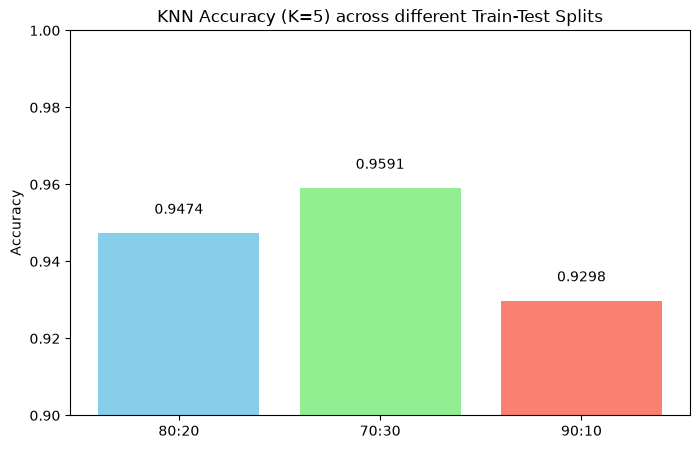

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

splits = [(0.2, '80:20'), (0.3, '70:30'), (0.1, '90:10')]
results = {}

for test_size, name in splits:
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=test_size, random_state=42)
    
    # Train a basic KNN (k=5)
    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_train, y_train)
    
    y_pred = knn.predict(X_test)
    results[name] = accuracy_score(y_test, y_pred)

# Plotting the results
plt.figure(figsize=(8, 5))
plt.bar(results.keys(), results.values(), color=['skyblue', 'lightgreen', 'salmon'])
plt.ylabel('Accuracy')
plt.title('KNN Accuracy (K=5) across different Train-Test Splits')
plt.ylim(0.9, 1.0)
for i, v in enumerate(results.values()):
    plt.text(i, v + 0.005, f"{v:.4f}", ha='center')
plt.show()


**Analysis of Dataset Splitting:**
Different splits lead to variations in accuracy because the model trains on slightly different subsets of data. A 90:10 split provides more training data, potentially capturing more patterns, but evaluates on less data, leading to higher variance in the evaluation metric. An 80:20 or 70:30 split generally provides a good balance for model stability and generalization.


## Task 3: KNN Model with Heuristic K Selection


In [4]:
import math

# Heuristic K selection: K = sqrt(n) where n is number of training samples (using 80:20 split)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
n = X_train.shape[0]
heuristic_k = int(math.sqrt(n))

# Ensure K is odd to avoid ties in binary classification
if heuristic_k % 2 == 0:
    heuristic_k += 1

print(f"Number of training samples (n): {n}")
print(f"Heuristic K value (sqrt(n)): {heuristic_k}")


Number of training samples (n): 455
Heuristic K value (sqrt(n)): 21


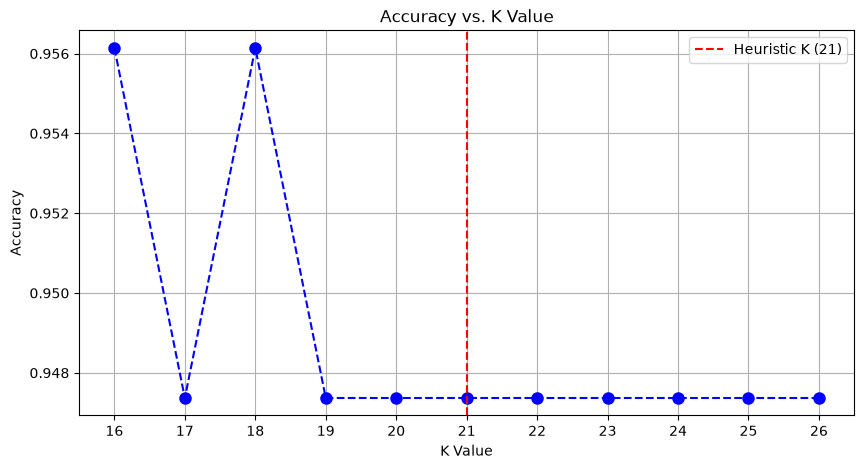

Optimal K based on testing: 16


In [5]:
# Experimenting with K values
k_values = range(max(1, heuristic_k - 5), heuristic_k + 6)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    accuracies.append(accuracy_score(y_test, y_pred))

plt.figure(figsize=(10, 5))
plt.plot(k_values, accuracies, marker='o', linestyle='dashed', color='b', markersize=8)
plt.axvline(x=heuristic_k, color='r', linestyle='--', label=f'Heuristic K ({heuristic_k})')
plt.title('Accuracy vs. K Value')
plt.xlabel('K Value')
plt.ylabel('Accuracy')
plt.xticks(k_values)
plt.legend()
plt.grid(True)
plt.show()

optimal_k = k_values[np.argmax(accuracies)]
print(f"Optimal K based on testing: {optimal_k}")


### 3.3 Distance Matrix and Decision Boundary Mapping

**Distance Metrics:**
1. **Euclidean Distance**: Computes the straight-line distance between two points. It is best suited for continuous variables when all features are on the same scale (which is why scaling is important).
2. **Manhattan Distance**: Computes distance along axes at right angles. It is suitable when features are discrete/categorical or when the data has a very high dimensionality and is less affected by outliers.


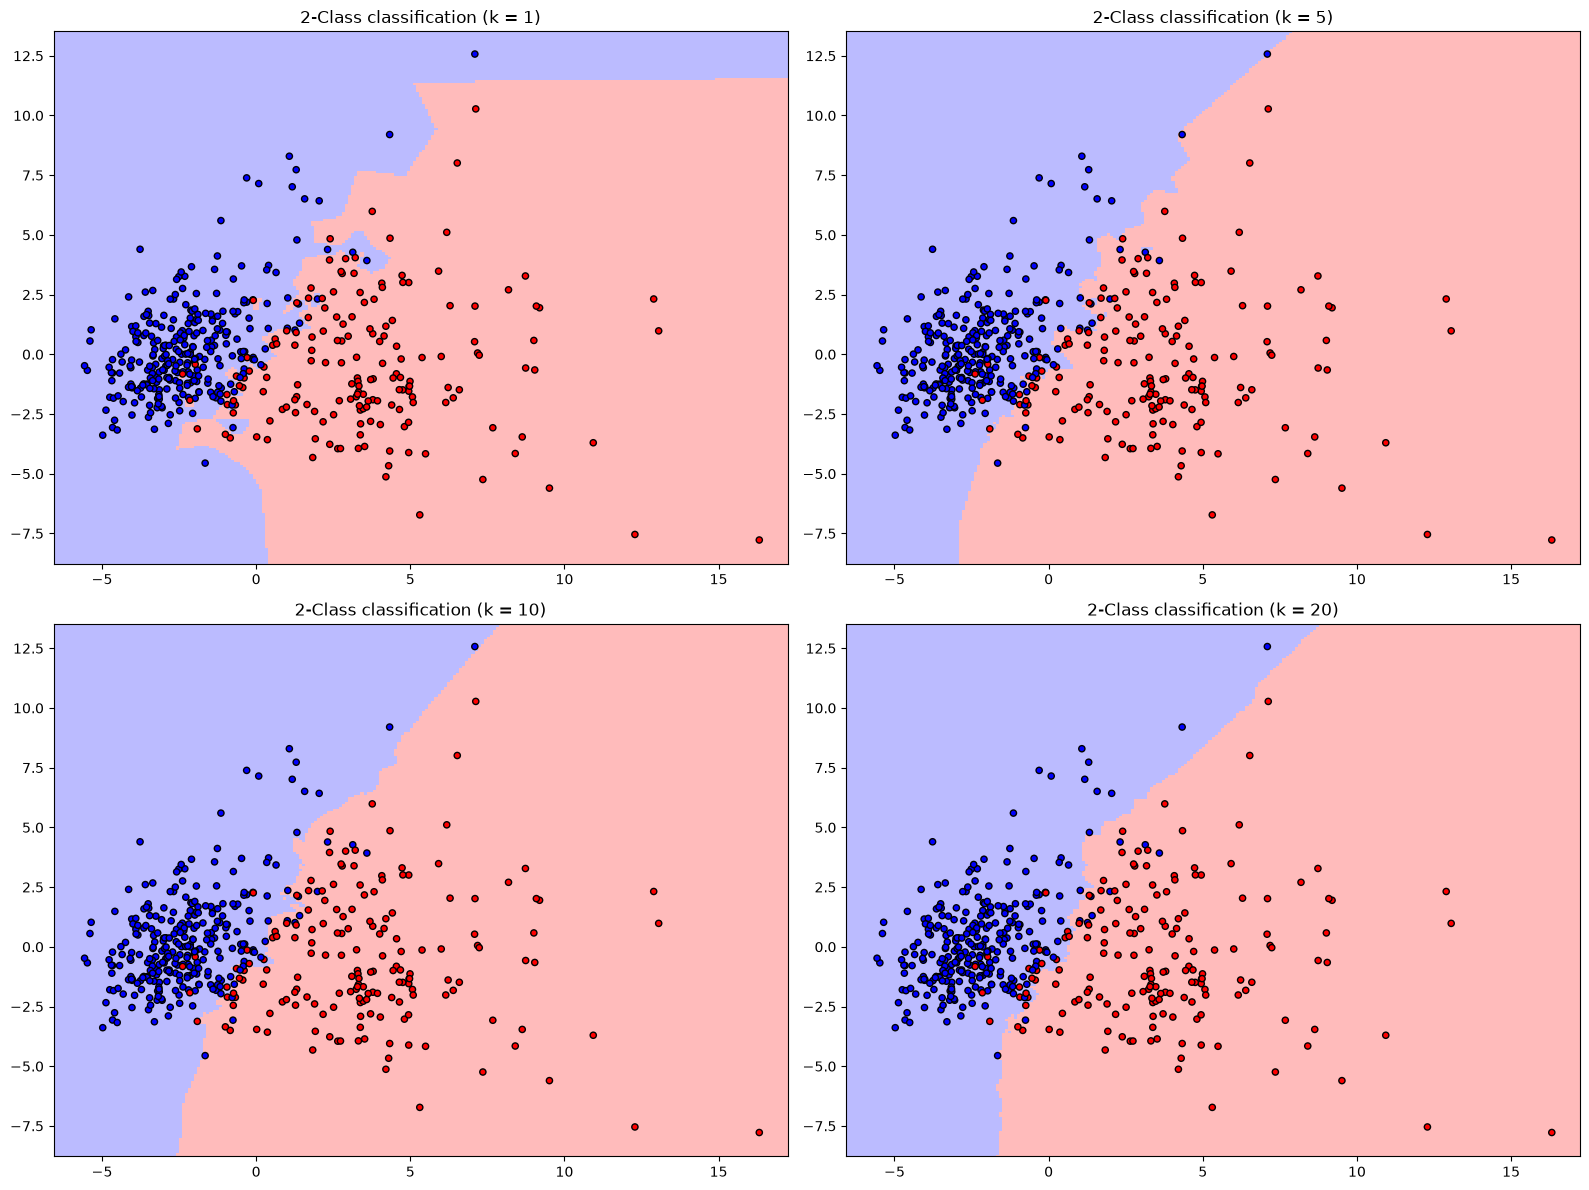

In [6]:
from matplotlib.colors import ListedColormap
from sklearn.decomposition import PCA

# To visualize decision boundaries, we need to reduce the dataset to 2 dimensions using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(X_pca, y, test_size=0.2, random_state=42)

k_list = [1, 5, 10, 20]
plt.figure(figsize=(16, 12))

cmap_light = ListedColormap(['#FFAAAA', '#AAAAFF'])
cmap_bold = ListedColormap(['#FF0000', '#0000FF'])

for i, k in enumerate(k_list, 1):
    knn_pca = KNeighborsClassifier(n_neighbors=k)
    knn_pca.fit(X_train_pca, y_train_pca)
    
    # Plotting decision regions
    x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
    y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                         np.arange(y_min, y_max, 0.1))
    
    Z = knn_pca.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.subplot(2, 2, i)
    plt.pcolormesh(xx, yy, Z, cmap=cmap_light, alpha=0.8)
    
    # Plot also the training points
    plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train_pca, cmap=cmap_bold, edgecolor='k', s=20)
    plt.title(f"2-Class classification (k = {k})")
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())

plt.tight_layout()
plt.show()


**Decision Boundary Analysis:** As K increases, the decision boundary becomes smoother and less complex. When K=1, the model captures noise in the training data (overfitting) and creates highly irregular boundaries. For larger K (e.g., K=20), the boundary is smoother and more generalized, reducing variance but potentially increasing bias (underfitting if K is too large).


## Task 4: Cross Validation
Applying K-Fold Cross Validation to ensure robustness.


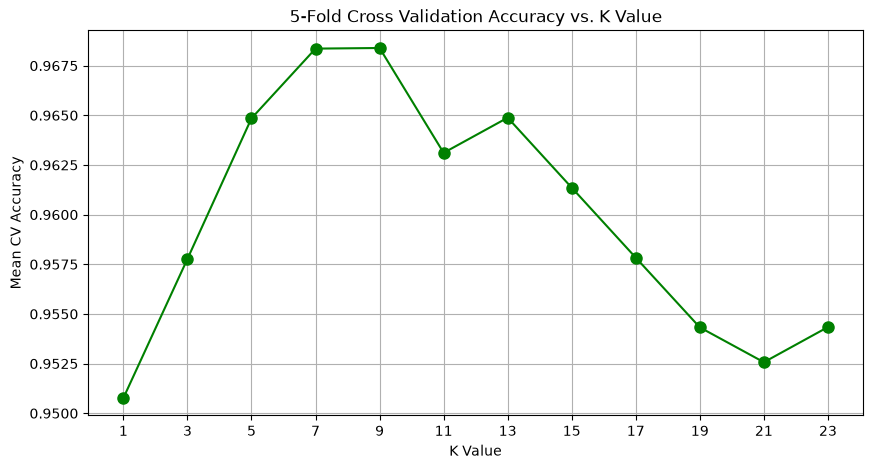

Best K based on Cross-Validation: 9


In [7]:
from sklearn.model_selection import cross_val_score

k_folds = 5
cv_scores = []
k_range = range(1, 25, 2) # Test odd numbers from 1 to 23

for k in k_range:
    knn_cv = KNeighborsClassifier(n_neighbors=k)
    # Applying CV on the whole dataset to find optimal global K
    scores = cross_val_score(knn_cv, X_scaled, y, cv=k_folds, scoring='accuracy')
    cv_scores.append(scores.mean())

plt.figure(figsize=(10, 5))
plt.plot(k_range, cv_scores, marker='o', linestyle='-', color='g', markersize=8)
plt.title(f'{k_folds}-Fold Cross Validation Accuracy vs. K Value')
plt.xlabel('K Value')
plt.ylabel('Mean CV Accuracy')
plt.xticks(k_range)
plt.grid(True)
plt.show()

best_k_cv = k_range[np.argmax(cv_scores)]
print(f"Best K based on Cross-Validation: {best_k_cv}")


## Task 5: Classification Evaluation


Accuracy: 0.9649
Precision: 0.9718
Recall: 0.9718
F1 Score: 0.9718



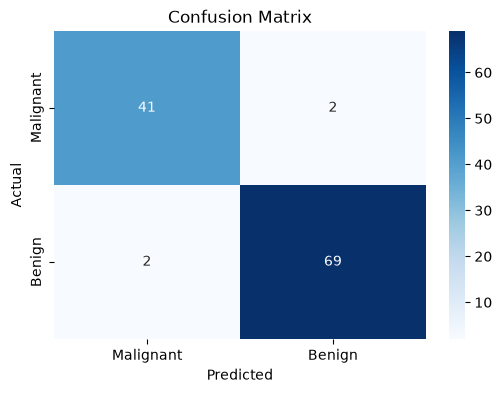

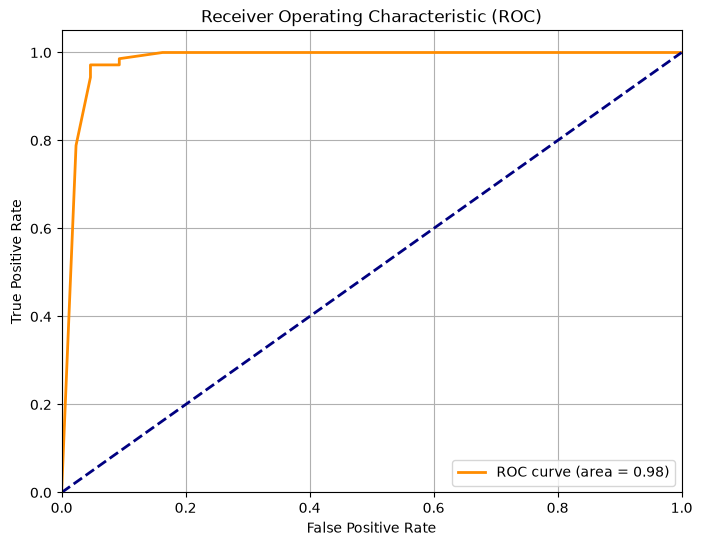

In [8]:
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, precision_score, recall_score, f1_score

# Using the best K from CV
final_knn = KNeighborsClassifier(n_neighbors=best_k_cv)
final_knn.fit(X_train, y_train)
y_pred_final = final_knn.predict(X_test)
y_prob = final_knn.predict_proba(X_test)[:, 1]

# Metrics
acc = accuracy_score(y_test, y_pred_final)
prec = precision_score(y_test, y_pred_final)
rec = recall_score(y_test, y_pred_final)
f1 = f1_score(y_test, y_pred_final)

print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1 Score: {f1:.4f}\n")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Malignant', 'Benign'], yticklabels=['Malignant', 'Benign'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


## Task 6: Comparative Study with Regression (Lab 3 Integration)

### Inference:



- **How regression metrics measure prediction error magnitude:** Regression metrics (MAE, MSE, RMSE) quantify the physical difference between predicted numerical values and actual values. They measure *how far off* the predictions are.
- **How classification metrics measure decision correctness:** Classification metrics (Accuracy, Precision, Recall) evaluate whether the predicted category matches the true category. They measure *if the model made the right choice*, regardless of "how close" it was mathematically.
- **Why is accuracy insufficient in medical diagnosis:** Accuracy can be misleading in imbalanced datasets (e.g., if 99% of patients don't have cancer, a model predicting "no cancer" for everyone is 99% accurate, but fails to identify any sick patients). 
- **Why recall and ROC-AUC are more relevant in healthcare:** In cancer prediction, missing a positive case (False Negative) is fatal. Recall focuses on minimizing False Negatives (identifying all actual cancer cases). ROC-AUC shows the model's ability to distinguish between classes across different thresholds.
- **Overall comparison between regression and classification evaluation frameworks:** Regression evaluates continuous magnitude errors, while classification evaluates discrete decision boundaries. An $R^2$ score represents variance explained in regression, comparable conceptually to Accuracy in classification. RMSE represents average deviation, whereas F1 score represents the harmonic mean of precision and recall. MAE shows average absolute error, while a Confusion Matrix breaks down exact counts of true/false positive/negative decisions.



## Task 7: Analytical Questions

1. **Why is KNN called a lazy learning algorithm?**
It does not 'learn' a discriminative function from the training data during the training phase. It simply stores the training dataset and delays all computation until a prediction is requested.

2. **Why is feature scaling required in KNN?**
Since it calculates distances (like Euclidean), features with larger numeric ranges will unfairly dominate the distance calculation over features with smaller ranges.

3. **Explain heuristic K selection using $\sqrt{n}$ rule.**
A common rule of thumb is setting $K = \sqrt{n}$, where $n$ is the number of training samples. This provides a balance, ensuring $K$ grows slowly with dataset size to reduce noise without over-smoothing.

4. **Why is cross-validation more reliable than a single train-test split?**
It trains and tests the model on multiple different subsets of the data, reducing the risk that high performance was achieved purely by a 'lucky' train-test split.

5. **How does K affect bias-variance trade-off?**
Small K = Low Bias, High Variance (overfitting, captures noise). Large K = High Bias, Low Variance (underfitting, overly smoothed boundaries).

6. **Why is recall more important than accuracy in cancer prediction?**
Missing a cancer diagnosis (False Negative) is much more dangerous than a false alarm (False Positive). Recall focuses specifically on finding all actual positive (cancer) cases.

7. **What is the limitation of very large K values?**
If K is too large, the model becomes too rigid (high bias) and essentially predicts the majority class for all points, ignoring local structures in the data.


## Conclusion

In this lab, we successfully applied K-Nearest Neighbors (KNN) to classify the Breast Cancer dataset. We found that the heuristic $\sqrt{n}$ provided a reasonable baseline for $K$, but Cross-Validation was necessary to pinpoint the optimal $K$ value for this specific dataset. We observed that different Train-Test splits yield fluctuating accuracies, highlighting the importance of robust evaluation techniques like K-Fold CV. 

Our evaluation showed that while accuracy is high, considering Recall and ROC-AUC is paramount in the medical domain. Finally, comparing this to Lab 3, we understand that classification relies on decision-correctness (confusion matrix, recall) rather than error-magnitude (MSE, MAE) used in regression.
